# Physics Integrator Benchmark — Analysis & Visualisation

Analyses two CSV files produced by the C++ benchmark:
- **`benchmark.csv`** — aggregated metrics per (solver, dt)
- **`energy_drift.csv`** — E(t) time series for selected dt values

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

SOLVER_STYLE = {
    "Euler": {"color": "#E24B4A", "marker": "o", "ls": "-"},
    "Verlet": {"color": "#378ADD", "marker": "s", "ls": "--"},
    "RK4": {"color": "#1D9E75", "marker": "^", "ls": "-."},
}

ABOX = dict(boxstyle="round,pad=0.4", fc="white", ec="#cccccc", alpha=0.92, lw=0.8)


def solver_legend(ax, loc="lower right"):
    handles = [
        Line2D(
            [0],
            [0],
            color=s["color"],
            marker=s["marker"],
            linestyle=s["ls"],
            label=name,
            markersize=6,
        )
        for name, s in SOLVER_STYLE.items()
    ]
    ax.legend(handles=handles, framealpha=0.5, loc=loc)


BENCHMARK_CSV = Path("benchmark.csv")
ENERGY_DRIFT_CSV = Path("energy_drift.csv")

df = pd.read_csv(BENCHMARK_CSV)
ede = pd.read_csv(ENERGY_DRIFT_CSV)
df_valid = df.dropna(subset=["contact_error"]).copy()

print(f"benchmark.csv    : {len(df)} rows")
print(f"energy_drift.csv : {len(ede)} rows")

benchmark.csv    : 150 rows
energy_drift.csv : 6117 rows


## Plot 1 — Contact time error vs dt (convergence order)

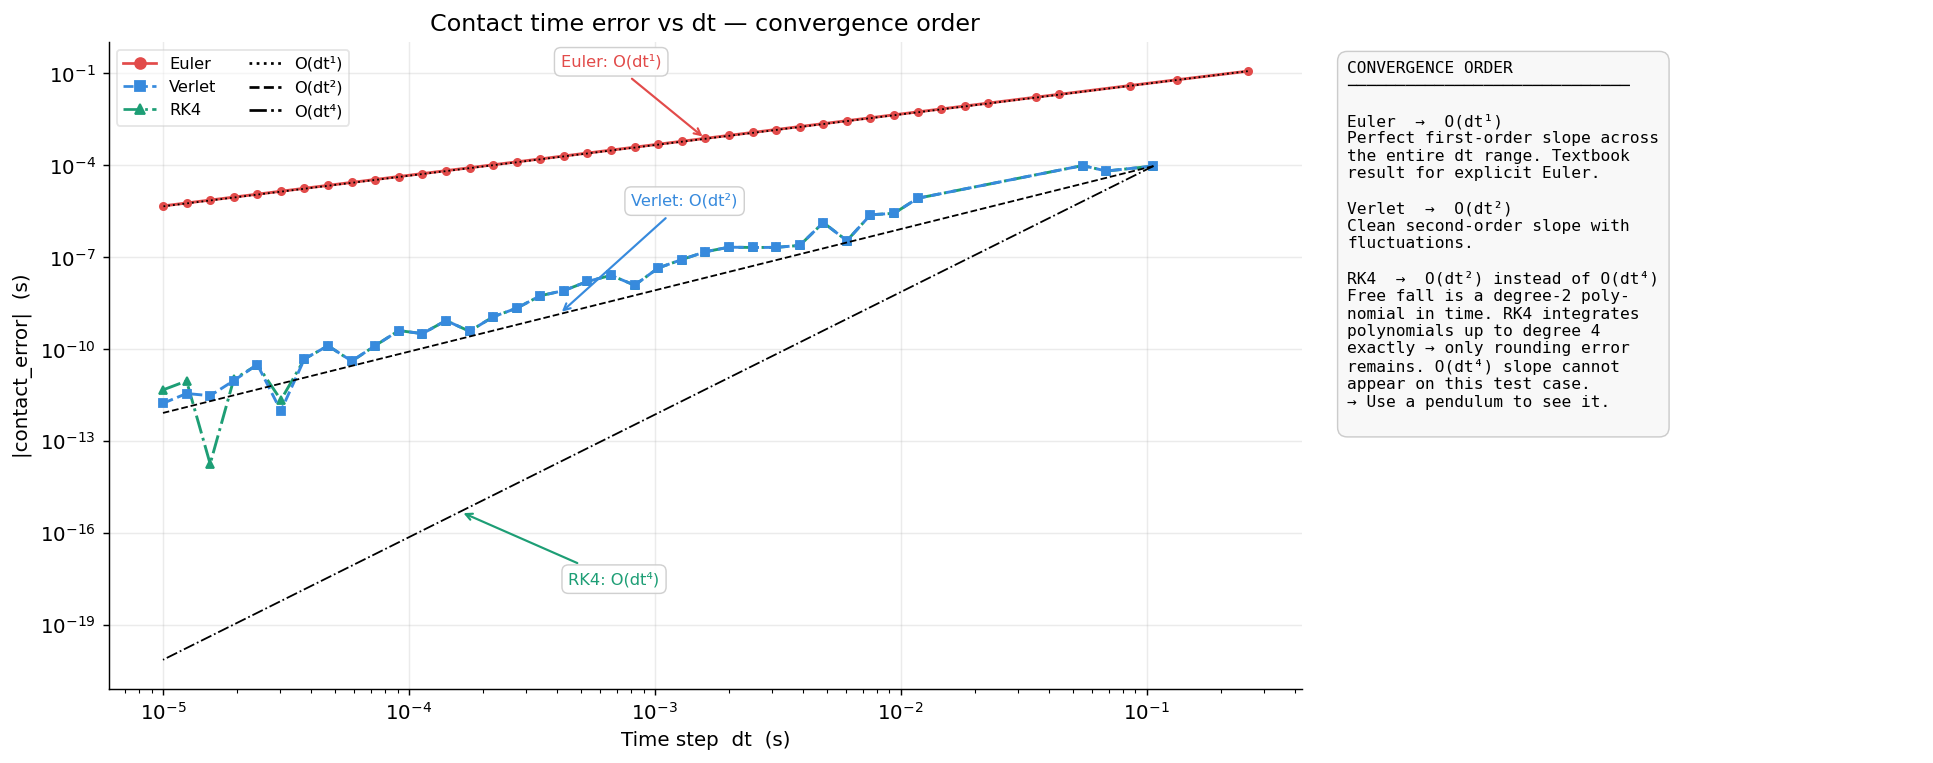

In [2]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df_valid.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.loglog(
        grp["dt"],
        grp["contact_error"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

orders = [1, 2, 4]
styles = ["k:", "k--", "k-."]
ref_lines = []

for i, (solver, grp) in enumerate(df_valid.groupby("solver")):
    grp = grp.sort_values("dt")

    dt_vals = grp["dt"].values
    dt_min, dt_max = dt_vals[0], dt_vals[-1]

    # anchor at LAST point (what you want)
    dt0 = dt_max
    y0  = grp["contact_error"].iloc[-1]

    p = orders[i]

    # build reference line going LEFT (toward smaller dt)
    dt_ref = np.array([dt_max, dt_min])
    y_ref = y0 * (dt_ref / dt0)**p

    ax.loglog(dt_ref, y_ref, styles[i], linewidth=1, label=f"O(dt^{p})")

    ref_lines.append((dt_ref, y_ref))
    
def point_on_line(dt_ref, y_ref, t=0.6):
    x = dt_ref[0]**(1-t) * dt_ref[1]**t
    y = y_ref[0]**(1-t) * y_ref[1]**t
    return x, y

# Euler
x, y = point_on_line(*ref_lines[0], t=0.5)
ax.annotate(
    "Euler: O(dt¹)",
    xy=(x, y),
    xytext=(-80, 40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
    color="#E24B4A",
    fontsize=9,
    bbox=ABOX,
)

# Verlet
x, y = point_on_line(*ref_lines[1], t=0.6)
ax.annotate(
    "Verlet: O(dt²)",
    xy=(x, y),
    xytext=(40, 60),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD",
    fontsize=9,
    bbox=ABOX,
)

# RK4
x, y = point_on_line(*ref_lines[2], t=0.7)
ax.annotate(
    "RK4: O(dt⁴)",
    xy=(x, y),
    xytext=(60, -40),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75",
    fontsize=9,
    bbox=ABOX,
)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|contact_error|  (s)")
ax.set_title("Contact time error vs dt — convergence order")

handles_solvers = [
    Line2D([0], [0], color=s["color"], marker=s["marker"], ls=s["ls"], label=k, markersize=6)
    for k, s in SOLVER_STYLE.items()
]
handles_refs = [
    Line2D([0], [0], color="k", ls=":", label="O(dt¹)"),
    Line2D([0], [0], color="k", ls="--", label="O(dt²)"),
    Line2D([0], [0], color="k", ls="-.", label="O(dt⁴)"),
]
ax.legend(
    handles=handles_solvers + handles_refs, fontsize=9, framealpha=0.5, ncol=2, loc="upper left"
)

# Side notes panel
ax_notes.axis("off")
notes = (
    "CONVERGENCE ORDER\n"
    "─────────────────────────────\n\n"
    "Euler  →  O(dt¹)\n"
    "Perfect first-order slope across\n"
    "the entire dt range. Textbook\n"
    "result for explicit Euler.\n\n"
    "Verlet  →  O(dt²)\n"
    "Clean second-order slope with \n"
    "fluctuations.\n\n"
    "RK4  →  O(dt²) instead of O(dt⁴)\n"
    "Free fall is a degree-2 poly-\n"
    "nomial in time. RK4 integrates\n"
    "polynomials up to degree 4\n"
    "exactly → only rounding error\n"
    "remains. O(dt⁴) slope cannot\n"
    "appear on this test case.\n"
    "→ Use a pendulum to see it.\n"
)
ax_notes.text(
    0.04,
    0.97,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

plt.tight_layout()
plt.savefig("plot_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 2 — Max energy drift vs dt

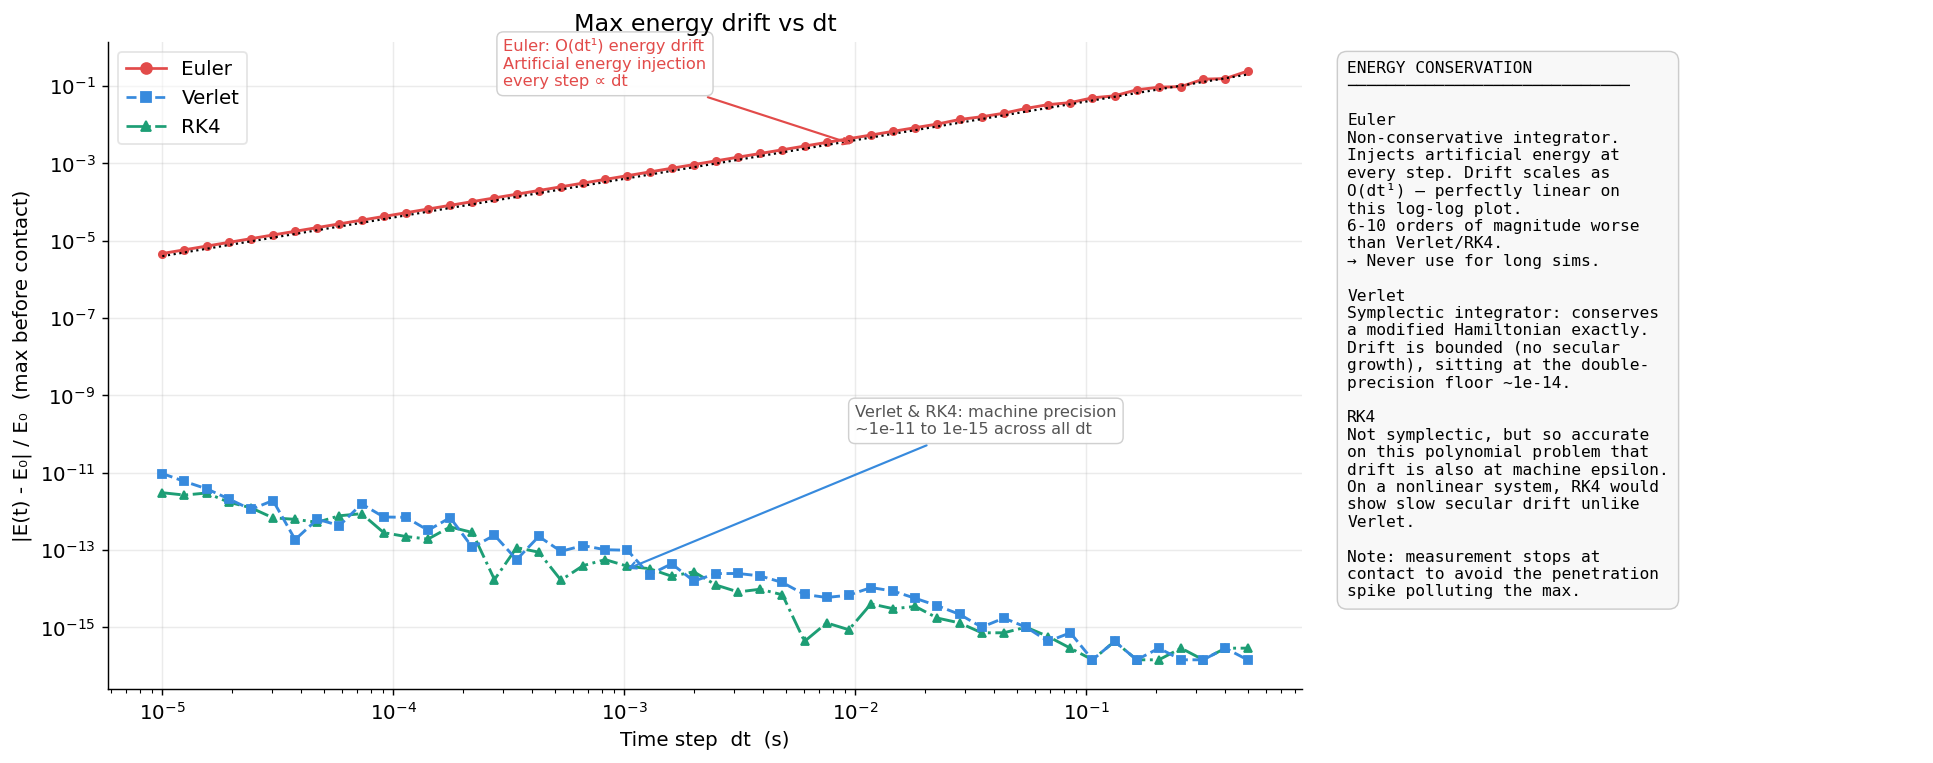

In [ ]:
fig, (ax, ax_notes) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [2, 1]}
)

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    mask = grp["max_energy_drift"] > 0
    ax.loglog(grp.loc[mask, "dt"], grp.loc[mask, "max_energy_drift"],
              color=s["color"], marker=s["marker"], ls=s["ls"],
              markersize=4, linewidth=1.6)

# Reference O(dt) slope for Euler
dt_ref = np.array([1e-5, 5e-1])
ax.loglog(dt_ref, 4e-1 * dt_ref**1, "k:", linewidth=1.2, label="O(dt¹) ref")

# ── Annotations ──────────────────────────────────────────────────────────────
ax.annotate("Euler: O(dt¹) energy drift\nNumerical energy injection\nevery step ∝ dt",
            xy=(1e-2, 3e-3), xytext=(3e-4, 1e-1),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
            color="#E24B4A", fontsize=9, bbox=ABOX)

ax.annotate("Verlet & RK4: machine precision\n~1e-11 to 1e-15 across all dt",
            xy=(1e-3, 3e-14), xytext=(1e-2, 1e-10),
            arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
            color="#555", fontsize=9, bbox=ABOX)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("|E(t) - E₀| / E₀  (max before contact)")
ax.set_title("Max energy drift vs dt")
solver_legend(ax, loc="upper left")

# ── Side notes ────────────────────────────────────────────────────────────────
ax_notes.axis("off")
notes = (
    "ENERGY CONSERVATION\n"
    "─────────────────────────────\n\n"
    "Euler\n"
    "Non-conservative integrator.\n"
    "Injects artificial energy at\n"
    "every step. Drift scales as\n"
    "O(dt¹) — perfectly linear on\n"
    "this log-log plot.\n"
    "6-10 orders of magnitude worse\n"
    "than Verlet/RK4.\n"
    "→ Never use for long sims.\n\n"
    "Verlet\n"
    "Symplectic integrator: conserves\n"
    "a modified Hamiltonian exactly.\n"
    "Drift is bounded (no secular\n"
    "growth), sitting at the double-\n"
    "precision floor ~1e-14.\n\n"
    "RK4\n"
    "Not symplectic, but so accurate\n"
    "on this polynomial problem that\n"
    "drift is also at machine epsilon.\n"
    "On a nonlinear system, RK4 would\n"
    "show slow secular drift unlike\n"
    "Verlet.\n\n"
    "Note: measurement stops at\n"
    "contact to avoid the penetration\n"
    "spike polluting the max."
)
ax_notes.text(0.04, 0.97, notes, transform=ax_notes.transAxes,
              fontsize=9, va="top", family="monospace",
              bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8))

plt.tight_layout()
plt.savefig("plot_energy_drift_vs_dt.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 3 — Cost vs precision

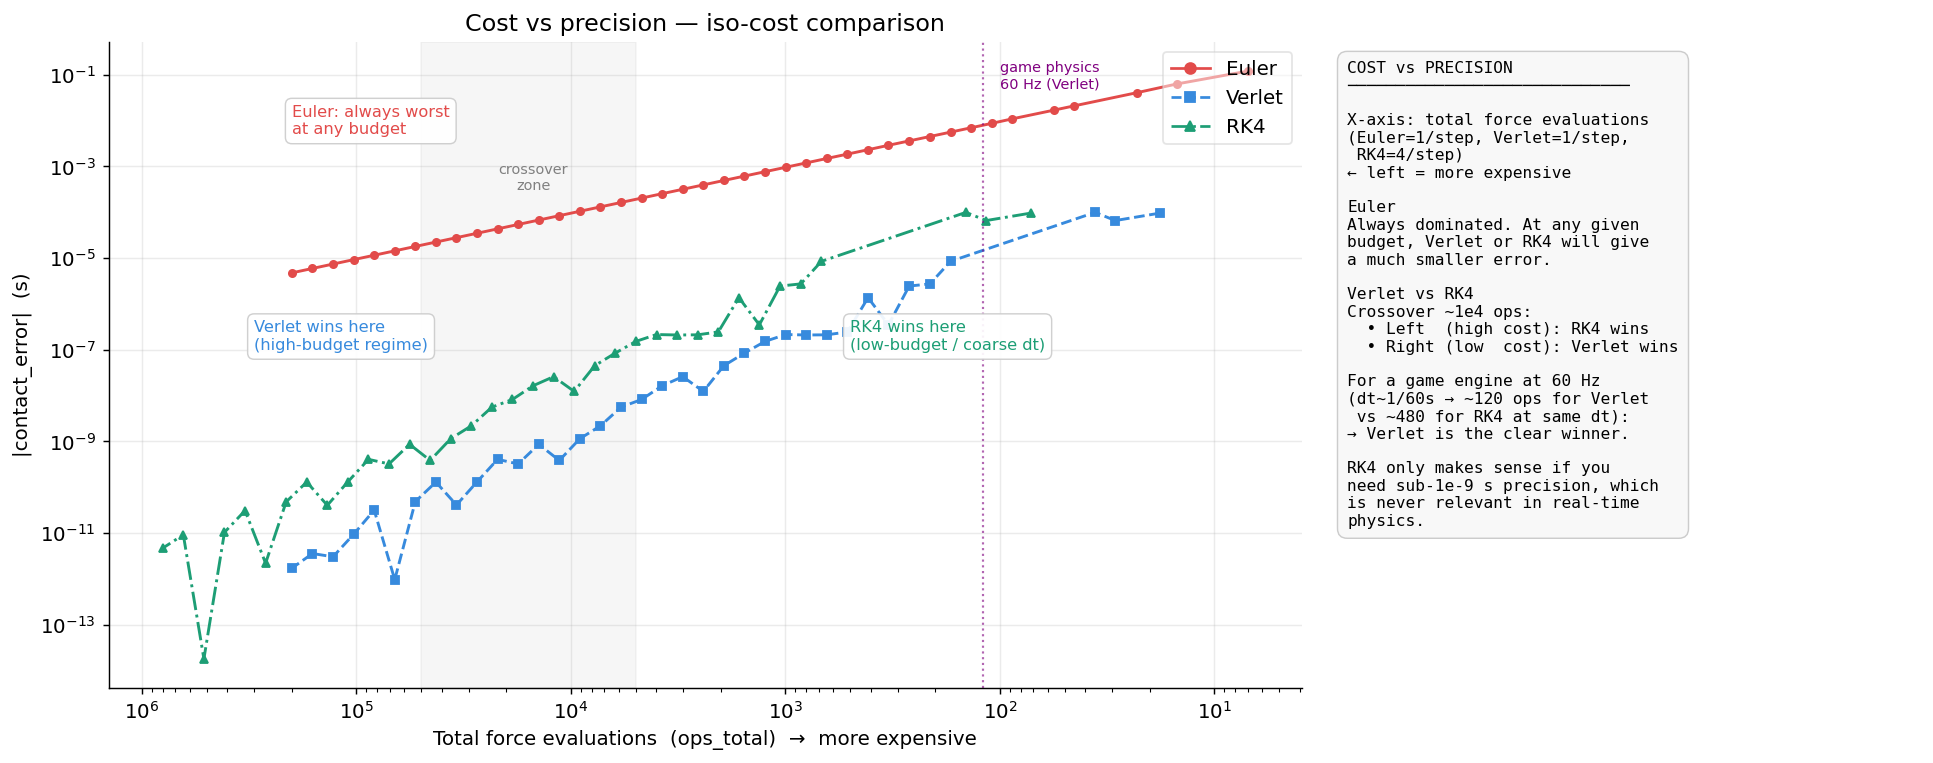

In [4]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df_valid.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("ops_total")
    mask = grp["contact_error"] > 0
    ax.loglog(
        grp.loc[mask, "ops_total"],
        grp.loc[mask, "contact_error"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

# Crossover region ─────────────────────────────────────────────────────────
ax.axvspan(5e3, 5e4, alpha=0.07, color="gray")
ax.text(1.5e4, 3e-4, "crossover\nzone", fontsize=8, color="gray", ha="center")

# Annotations 
ax.annotate(
    "Euler: always worst\nat any budget",
    xy=(1e4, 1e-3),
    xytext=(2e5, 5e-3),
    # arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1.2),
    color="#E24B4A",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    "Verlet wins here\n(high-budget regime)",
    xy=(3e4, 3e-9),
    xytext=(3e5, 1e-7),
    # arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    "RK4 wins here\n(low-budget / coarse dt)",
    xy=(2e2, 3e-10),
    xytext=(5e2, 1e-7),
    # arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75",
    fontsize=9,
    bbox=ABOX,
)

# Mark real-time game physics region (dt~1/60 → ops~120 for Verlet)
ax.axvline(120, color="purple", ls=":", lw=1.2, alpha=0.6)
ax.text(100, 2e-1, "game physics\n60 Hz (Verlet)", fontsize=8, color="purple", va="top")

ax.set_xlabel("Total force evaluations  (ops_total)  →  more expensive")
ax.set_ylabel("|contact_error|  (s)")
ax.set_title("Cost vs precision — iso-cost comparison")
ax.invert_xaxis()
solver_legend(ax, loc="upper right")

# Side notes
ax_notes.axis("off")
notes = (
    "COST vs PRECISION\n"
    "─────────────────────────────\n\n"
    "X-axis: total force evaluations\n"
    "(Euler=1/step, Verlet=1/step,\n"
    " RK4=4/step)\n"
    "← left = more expensive\n\n"
    "Euler\n"
    "Always dominated. At any given\n"
    "budget, Verlet or RK4 will give\n"
    "a much smaller error.\n\n"
    "Verlet vs RK4\n"
    "Crossover ~1e4 ops:\n"
    "  • Left  (high cost): RK4 wins\n"
    "  • Right (low  cost): Verlet wins\n\n"
    "For a game engine at 60 Hz\n"
    "(dt~1/60s → ~120 ops for Verlet\n"
    " vs ~480 for RK4 at same dt):\n"
    "→ Verlet is the clear winner.\n\n"
    "RK4 only makes sense if you\n"
    "need sub-1e-9 s precision, which\n"
    "is never relevant in real-time\n"
    "physics."
)
ax_notes.text(
    0.04,
    0.97,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

plt.tight_layout()
plt.savefig("plot_cost_vs_precision.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 4 — CPU time vs dt

/tmp/ipykernel_159155/442992492.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_at_mid[solver] = float(row["cpu_ms"])
/tmp/ipykernel_159155/442992492.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_at_mid[solver] = float(row["cpu_ms"])
/tmp/ipykernel_159155/442992492.py:26: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cpu_at_mid[solver] = float(row["cpu_ms"])


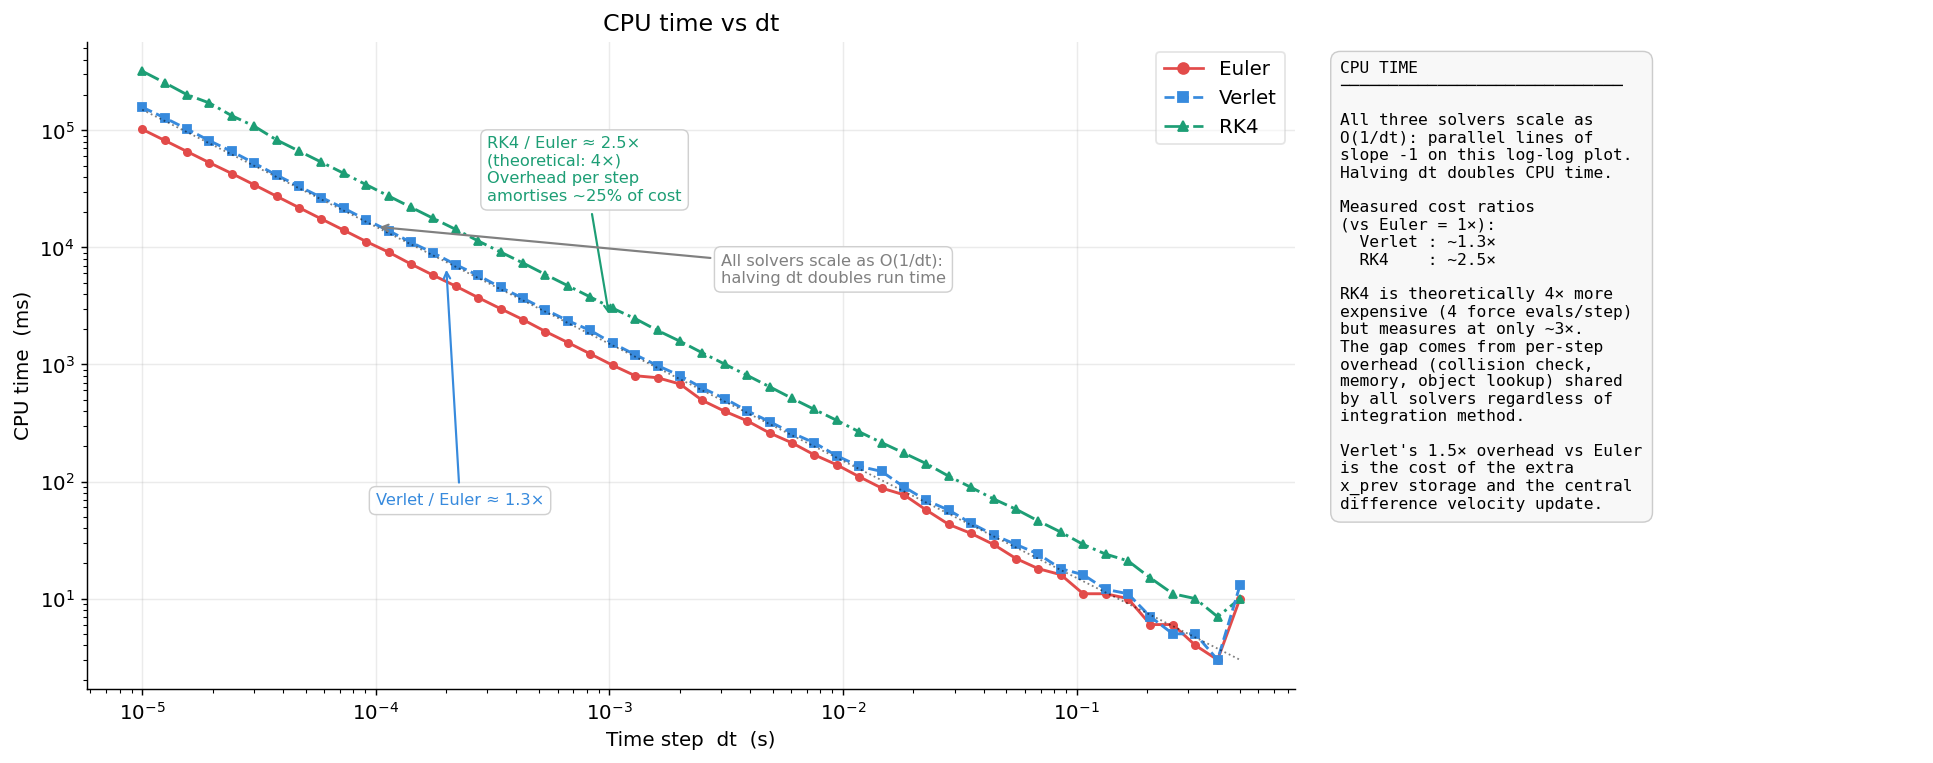

In [5]:
fig, (ax, ax_notes) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

for solver, grp in df.groupby("solver"):
    s = SOLVER_STYLE[solver]
    grp = grp.sort_values("dt")
    ax.loglog(
        grp["dt"],
        grp["cpu_ms"],
        color=s["color"],
        marker=s["marker"],
        ls=s["ls"],
        markersize=4,
        linewidth=1.6,
    )

# Reference O(1/dt) slope
dt_ref = np.array([1e-5, 5e-1])
ax.loglog(dt_ref, 1.5 / dt_ref, "k:", linewidth=1, alpha=0.5, label="O(1/dt) ref")

# Annotations 
# Compute actual ratios from data at middle dt
mid_dt = df["dt"].median()
cpu_at_mid = {}
for solver, grp in df.groupby("solver"):
    row = grp.iloc[(grp["dt"] - mid_dt).abs().argsort()[:1]]
    cpu_at_mid[solver] = float(row["cpu_ms"])

rk4_ratio = cpu_at_mid["RK4"] / cpu_at_mid["Euler"]
vlt_ratio = cpu_at_mid["Verlet"] / cpu_at_mid["Euler"]

ax.annotate(
    f"RK4 / Euler ≈ {rk4_ratio:.1f}×\n(theoretical: 4×)\nOverhead per step\namortises ~25% of cost",
    xy=(1e-3, cpu_at_mid["RK4"]* 2),
    xytext=(3e-4, cpu_at_mid["RK4"] * 20),
    arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2),
    color="#1D9E75",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    f"Verlet / Euler ≈ {vlt_ratio:.1f}×",
    xy=(2e-4, cpu_at_mid["Verlet"] * 11),
    xytext=(1e-4, cpu_at_mid["Verlet"] * 0.1),
    arrowprops=dict(arrowstyle="->", color="#378ADD", lw=1.2),
    color="#378ADD",
    fontsize=9,
    bbox=ABOX,
)

ax.annotate(
    "All solvers scale as O(1/dt):\nhalving dt doubles run time",
    xy=(1e-4, 1.5e4),
    xytext=(3e-3, 5e3),
    arrowprops=dict(arrowstyle="->", color="gray", lw=1.2),
    color="gray",
    fontsize=9,
    bbox=ABOX,
)

ax.set_xlabel("Time step  dt  (s)")
ax.set_ylabel("CPU time  (ms)")
ax.set_title("CPU time vs dt")
solver_legend(ax, loc="upper right")

# Side notes
ax_notes.axis("off")
notes = (
    "CPU TIME\n"
    "─────────────────────────────\n\n"
    "All three solvers scale as\n"
    "O(1/dt): parallel lines of\n"
    "slope -1 on this log-log plot.\n"
    "Halving dt doubles CPU time.\n\n"
    "Measured cost ratios\n"
    "(vs Euler = 1×):\n"
    f"  Verlet : ~{vlt_ratio:.1f}×\n"
    f"  RK4    : ~{rk4_ratio:.1f}×\n\n"
    "RK4 is theoretically 4× more\n"
    "expensive (4 force evals/step)\n"
    "but measures at only ~3×.\n"
    "The gap comes from per-step\n"
    "overhead (collision check,\n"
    "memory, object lookup) shared\n"
    "by all solvers regardless of\n"
    "integration method.\n\n"
    "Verlet's 1.5× overhead vs Euler\n"
    "is the cost of the extra\n"
    "x_prev storage and the central\n"
    "difference velocity update."
)
ax_notes.text(
    0.04,
    0.97,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

plt.tight_layout()
plt.savefig("plot_cpu_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Plot 5 — E(t) time series

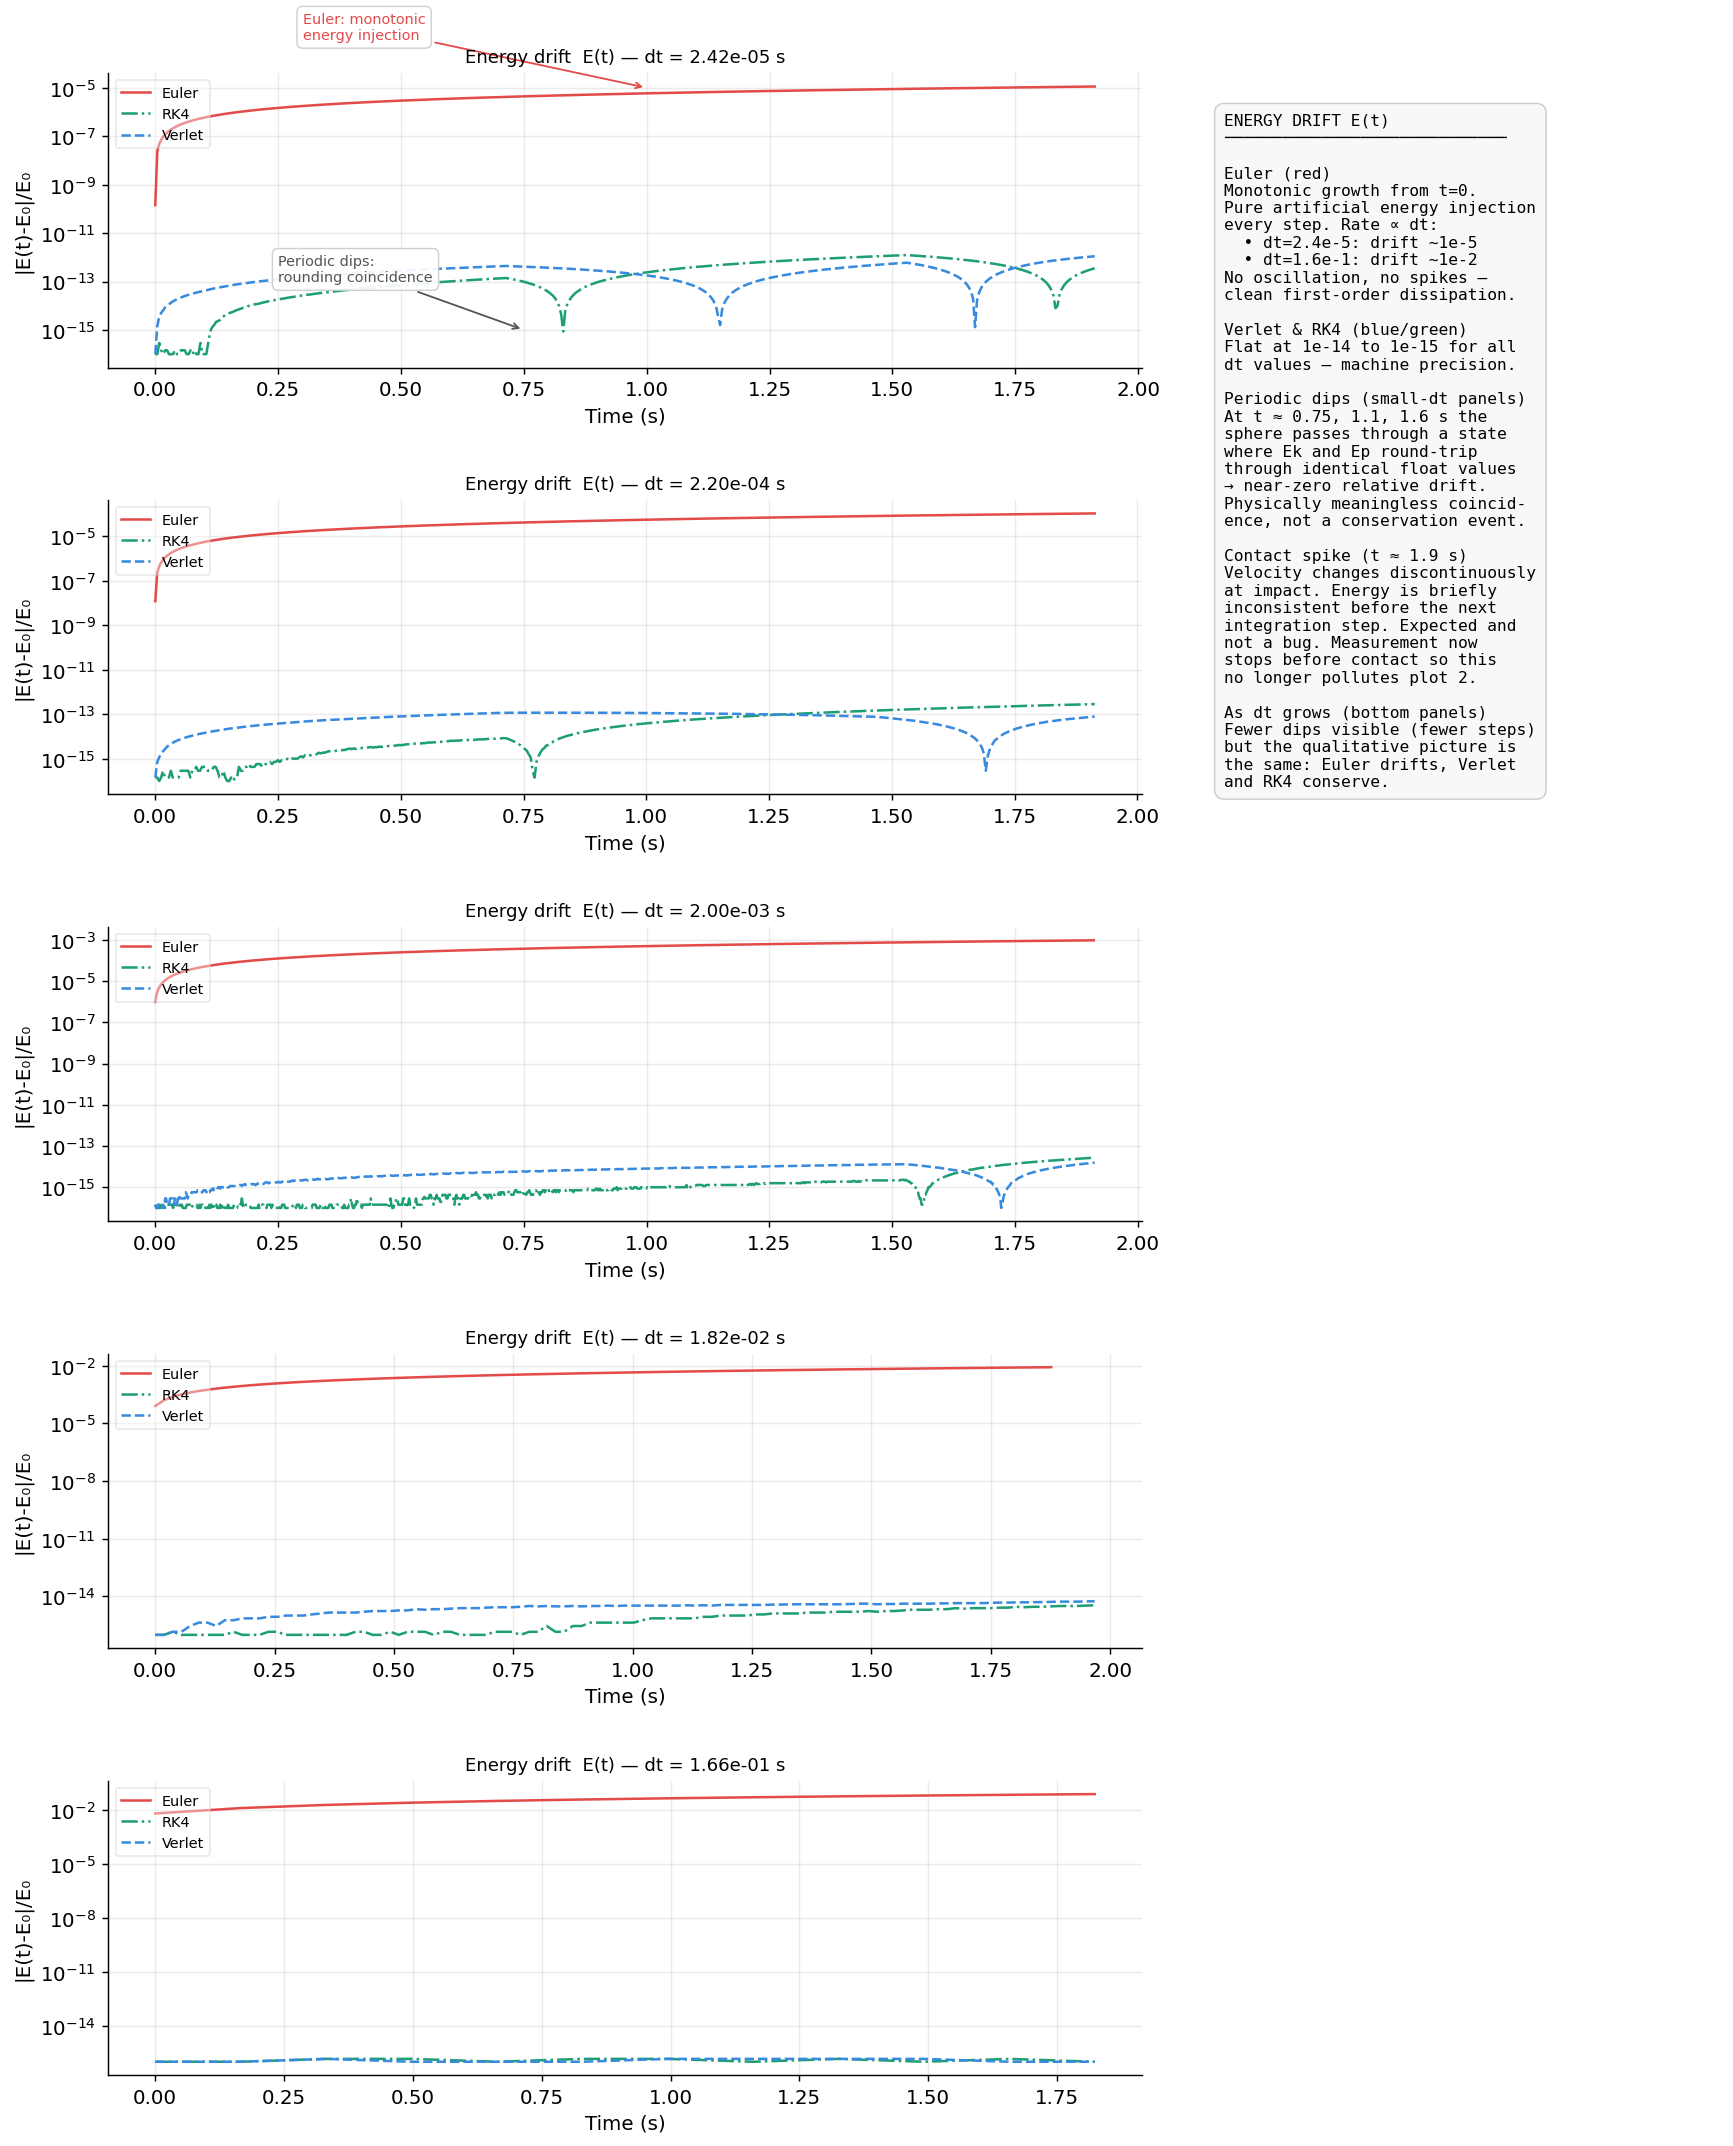

In [6]:
dt_values = sorted(ede["dt"].unique())
n_dt = len(dt_values)

fig = plt.figure(figsize=(16, 4.0 * n_dt))

# 2-column layout: plots on the left, one shared notes panel on the right
from matplotlib.gridspec import GridSpec

gs = GridSpec(n_dt, 2, figure=fig, width_ratios=[2, 1], hspace=0.45, wspace=0.08)

# Shared notes panel (spans all rows on the right) ─────────────────────────
ax_notes = fig.add_subplot(gs[:, 1])
ax_notes.axis("off")
notes = (
    "ENERGY DRIFT E(t)\n"
    "─────────────────────────────\n\n"
    "Euler (red)\n"
    "Monotonic growth from t=0.\n"
    "Pure artificial energy injection\n"
    "every step. Rate ∝ dt:\n"
    "  • dt=2.4e-5: drift ~1e-5\n"
    "  • dt=1.6e-1: drift ~1e-2\n"
    "No oscillation, no spikes —\n"
    "clean first-order dissipation.\n\n"
    "Verlet & RK4 (blue/green)\n"
    "Flat at 1e-14 to 1e-15 for all\n"
    "dt values — machine precision.\n\n"
    "Periodic dips (small-dt panels)\n"
    "At t ≈ 0.75, 1.1, 1.6 s the\n"
    "sphere passes through a state\n"
    "where Ek and Ep round-trip\n"
    "through identical float values\n"
    "→ near-zero relative drift.\n"
    "Physically meaningless coincid-\n"
    "ence, not a conservation event.\n\n"
    "Contact spike (t ≈ 1.9 s)\n"
    "Velocity changes discontinuously\n"
    "at impact. Energy is briefly\n"
    "inconsistent before the next\n"
    "integration step. Expected and\n"
    "not a bug. Measurement now\n"
    "stops before contact so this\n"
    "no longer pollutes plot 2.\n\n"
    "As dt grows (bottom panels)\n"
    "Fewer dips visible (fewer steps)\n"
    "but the qualitative picture is\n"
    "the same: Euler drifts, Verlet\n"
    "and RK4 conserve."
)
ax_notes.text(
    0.04,
    0.98,
    notes,
    transform=ax_notes.transAxes,
    fontsize=9,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round,pad=0.6", fc="#f8f8f8", ec="#cccccc", lw=0.8),
)

# Per-dt subplots ───────────────────────────────────────────────────────────
for i, dt_val in enumerate(dt_values):
    ax = fig.add_subplot(gs[i, 0])
    subset = ede[ede["dt"] == dt_val]

    for solver, grp in subset.groupby("solver"):
        s = SOLVER_STYLE[solver]
        grp = grp.sort_values("time")
        ax.semilogy(
            grp["time"],
            grp["energy_drift"].clip(lower=1e-16),
            color=s["color"],
            ls=s["ls"],
            linewidth=1.4,
            label=solver,
        )

    ax.set_title(f"Energy drift  E(t) — dt = {dt_val:.2e} s", fontsize=10)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("|E(t)-E₀|/E₀")
    ax.legend(fontsize=8, framealpha=0.4, loc="upper left")

    # Annotate Euler growth on first panel only
    if i == 0:
        ax.annotate(
            "Euler: monotonic\nenergy injection",
            xy=(1.0, 1e-5),
            xytext=(0.3, 1e-3),
            arrowprops=dict(arrowstyle="->", color="#E24B4A", lw=1),
            color="#E24B4A",
            fontsize=8,
            bbox=ABOX,
        )
        ax.annotate(
            "Periodic dips:\nrounding coincidence",
            xy=(0.75, 1e-15),
            xytext=(0.25, 1e-13),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1),
            color="#555",
            fontsize=8,
            bbox=ABOX,
        )

plt.savefig("plot_energy_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

## Convergence order — linear regression

In [7]:
print(f"{'Solver':<10} {'Estimated order':>16} {'R²':>8}  {'Interpretation'}")
print("-" * 70)

expected = {"Euler": 1, "Verlet": 2, "RK4": 4}
for solver, grp in df_valid.groupby("solver"):
    grp = grp.sort_values("dt")
    # Use only the sloped region: exclude the precision floor
    mask = (grp["contact_error"] > 1e-11) & (grp["contact_error"] > 0)
    if mask.sum() < 3:
        print(f"{solver:<10} {'not enough points':>16}")
        continue
    log_dt = np.log10(grp.loc[mask, "dt"])
    log_err = np.log10(grp.loc[mask, "contact_error"])
    slope, _, r, *_ = stats.linregress(log_dt, log_err)
    note = "✓ as expected" if abs(slope - expected[solver]) < 0.3 else "see notes above"
    print(f"{solver:<10} {slope:>16.3f} {r**2:>8.4f}  {note}")

Solver      Estimated order       R²  Interpretation
----------------------------------------------------------------------
Euler                 0.999   1.0000  ✓ as expected
RK4                   1.944   0.9842  see notes above
Verlet                1.934   0.9828  ✓ as expected


## Export all plots to PDF

In [8]:
from matplotlib.backends.backend_pdf import PdfPages

plot_files = [
    "plot_convergence.png",
    "plot_energy_drift_vs_dt.png",
    "plot_cost_vs_precision.png",
    "plot_cpu_time.png",
    "plot_energy_time_series.png",
]

with PdfPages("benchmark_report.pdf") as pdf:
    for path in plot_files:
        img = plt.imread(path)
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(img)
        ax.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("PDF saved to benchmark_report.pdf")

PDF saved to benchmark_report.pdf
